In [ ]:
from google.colab import files
uploaded = files.upload()

Saving listings.csv to listings.csv


In [ ]:
import pandas as pd

# Load the compressed CSV
df = pd.read_csv('listings.csv')

# View the first few rows
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,90676,https://www.airbnb.com/rooms/90676,20250624193419,2025-06-25,city scrape,Short North - Italianate Cottage,Just steps from High Street and all the action...,The Short North Italianate Cottage is located ...,https://a0.muscache.com/pictures/950e43cd-53f3...,483306,...,4.87,4.92,4.76,2022-2475,f,3,3,0,0,5.04
1,591101,https://www.airbnb.com/rooms/591101,20250624193419,2025-06-25,city scrape,Bellows Studio Loft Apartment,Famous American artist George Bellows home wit...,A historic neighborhood of beautiful victorian...,https://a0.muscache.com/pictures/32b28442-ddf3...,2889677,...,4.91,4.89,4.89,2019-1230,f,1,0,1,0,2.13
2,927867,https://www.airbnb.com/rooms/927867,20250624193419,2025-06-25,city scrape,Full Private Room at the Hostel,The Wayfaring Buckeye Hostel is a social place...,We are located in the vibrant University Distr...,https://a0.muscache.com/pictures/08033ebe-286c...,4965048,...,4.85,4.65,4.68,2019-1314,f,6,2,4,0,0.57
3,1183297,https://www.airbnb.com/rooms/1183297,20250624193419,2025-06-25,city scrape,Hannah's Haus**Prime location in German Village**,Hannah's Haus in German Village is a stunning ...,German Village is a historic neighborhood just...,https://a0.muscache.com/pictures/miso/Hosting-...,6473080,...,4.98,4.78,4.81,NaN,f,3,3,0,0,1.90
4,1217678,https://www.airbnb.com/rooms/1217678,20250624193419,2025-06-25,city scrape,Comfortable rooms in Clintonville 1,"A cozy, warm, inviting place to stay in the he...",The house is on a quiet and residential street...,https://a0.muscache.com/pictures/airflow/Hosti...,5707733,...,4.99,4.97,4.94,2023-4020,f,2,0,2,0,1.87


In [ ]:
print(df.shape)
print(df.columns)

# Summary statistics
df.describe()

# Missing values
df.isnull().sum().sort_values(ascending=False)

# Data types
df.dtypes

(2839, 79)
Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_av

,0
id,int64
listing_url,object
scrape_id,int64
last_scraped,object
source,object
...,...
calculated_host_listings_count,int64
calculated_host_listings_count_entire_homes,int64
calculated_host_listings_count_private_rooms,int64
calculated_host_listings_count_shared_rooms,int64


In [ ]:
# Clean the 'price' column
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


In [ ]:
# Group by neighborhood and calculate average price
df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)


,price
neighbourhood_cleansed,
Hayden Run,196.000000
Southeast,181.333333
Far South,179.000000
North Linden,156.333333
Clintonville,155.475728
Northwest,154.687500
Far Northwest,151.909091
Westland,147.714286
Far West,147.600000


<Axes: xlabel='room_type'>

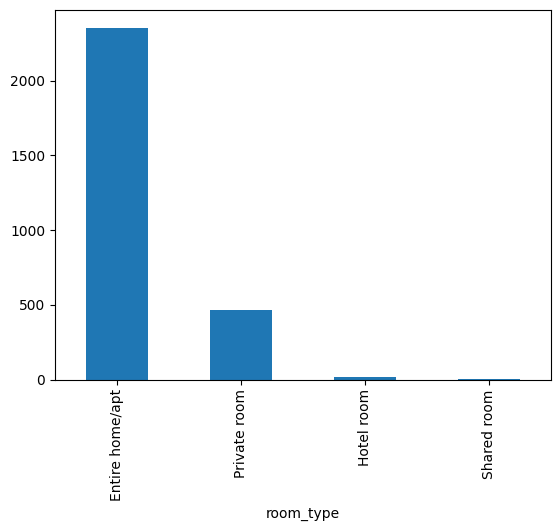

In [ ]:
df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

# Distribution of room types
df['room_type'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'Price Distribution')

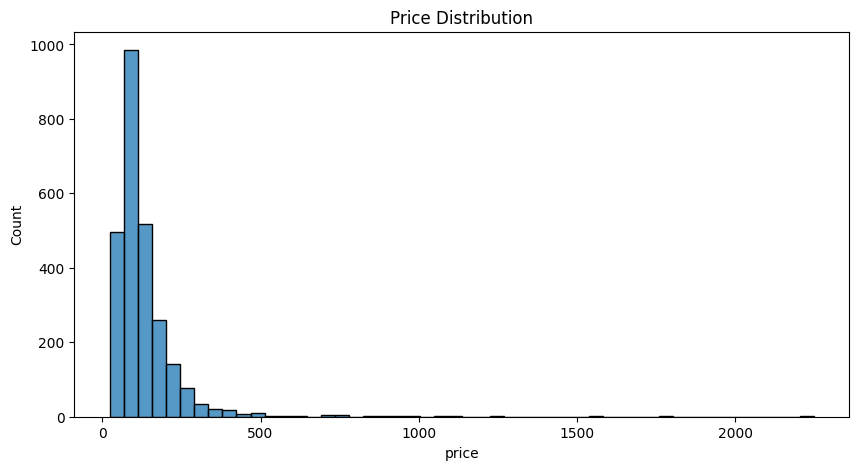

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of prices
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50)
plt.title('Price Distribution')


In [ ]:
import folium

map_airbnb = folium.Map(location=[df.latitude.mean(), df.longitude.mean()], zoom_start=12)
for _, row in df.sample(200).iterrows():
    folium.CircleMarker([row['latitude'], row['longitude']],
                        radius=1,
                        popup=row['name'],
                        fill_color="blue").add_to(map_airbnb)

map_airbnb


The folium map has markers that all look alike.  There is no visual encoding of price, value, or listing category.

In [ ]:
import folium
from folium.plugins import MarkerCluster

# Sample listings
sample = df[['latitude', 'longitude', 'price']].dropna().sample(300)

# Create map
map_airbnb = folium.Map(location=[sample.latitude.mean(), sample.longitude.mean()], zoom_start=12)
cluster = MarkerCluster().add_to(map_airbnb)

for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        popup=f"${row['price']}",
        color='blue' if row['price'] < 100 else 'red',
        fill=True,
        fill_opacity=0.6
    ).add_to(cluster)

map_airbnb


This new map contains color coded markers by price range.  The popups shows actual price on click.  MarkerCluster() groups nearby listings which helps reduce clutter.  The map gives visual cues about pricing patterns by area and not just by location.

In [ ]:
cols = ['price', 'reviews_per_month', 'number_of_reviews', 'availability_365']
corr_df = df[cols].copy()


In [ ]:
corr_df.dropna(inplace=True)


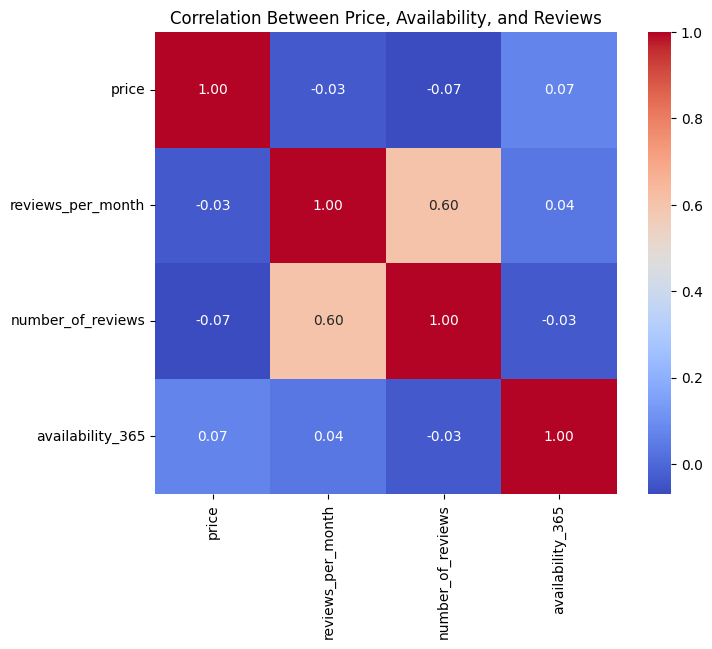

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = corr_df.corr()

# Plot the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Between Price, Availability, and Reviews')
plt.show()


This heatmap shows a strong correlation with the number of reviews and the number of reviews per month.  The variable names however have underscores in them.

In [ ]:
# Original columns using
cols = ['price', 'reviews_per_month', 'number_of_reviews', 'availability_365']

# Create a copy of the DataFrame
corr_df = df[cols].copy().dropna()

# Optional: clean up column names for readability
rename_map = {col: col.replace('_', ' ').title() for col in corr_df.columns}
corr_df.rename(columns=rename_map, inplace=True)


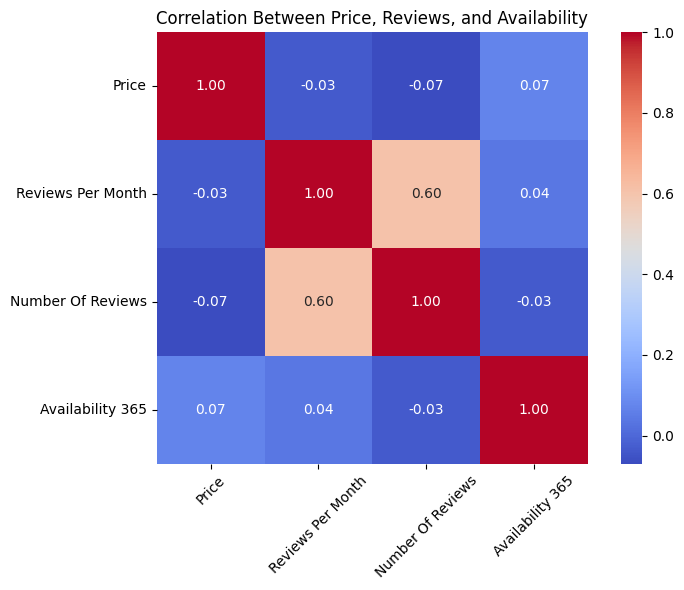

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Between Price, Reviews, and Availability')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Now that the correlation map is polished, the majority of the variables are not strongly correlated.  The most imporant correlation to look at it between any of the variables is with price.  To do this, I'll create a scatterplot that shows the relationship between Price and Reviews per Month.  This will show a more detailed relationship between Price and Reviews per Month compared to the heat map.

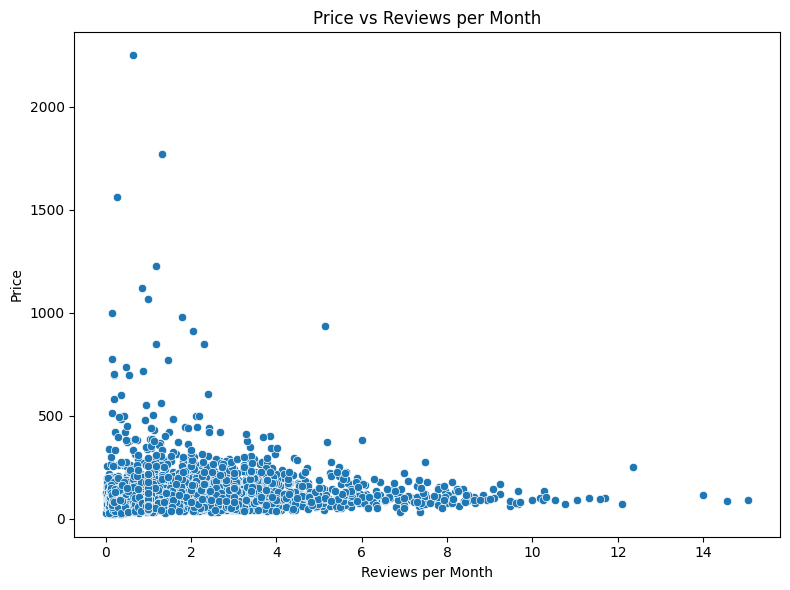

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='reviews_per_month', y='price')
plt.title('Price vs Reviews per Month')
plt.xlabel('Reviews per Month')  # Custom label without underscore
plt.ylabel('Price')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# One-hot encode categorical features
df_model = pd.get_dummies(df[['room_type', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'price']], drop_first=True)
df_model.dropna(inplace=True)

# Features and target
X = df_model.drop('price', axis=1)
y = df_model['price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² score:", r2_score(y_test, y_pred))


RMSE: 124.65274814374452
R² score: 0.046486575338232416


"RMSE: 124.65274814374452" means that on average the predictions are about $125 from the actual listing prices.  R² score: 0.046486575338232416 means that the variation in the price model is about 4.6.  There are outlighters in the pricing, some inconsistent data, and several airbnb prices are right-skewed, which can distort the model.  This is why this linear regression prediction model is performing poorly.

In [ ]:
y = np.log1p(df_model['price'])  # log(1 + price)


In [ ]:
predicted_prices = np.expm1(y_pred)


In [ ]:
['room_type', 'neighbourhood_cleansed', 'accommodates', 'bedrooms', 'review_scores_rating']


['room_type',
 'neighbourhood_cleansed',
 'accommodates',
 'bedrooms',
 'review_scores_rating']

In [ ]:
df = df[(df['price'] > 30) & (df['price'] < 1000)]


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# One-hot encode categorical features
df_model = pd.get_dummies(df[['room_type', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'price']], drop_first=True)
df_model.dropna(inplace=True)

# Features and target
X = df_model.drop('price', axis=1)
y = df_model['price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² score:", r2_score(y_test, y_pred))


RMSE: 82.35560321967468
R² score: 0.11083612618446492


My initial regression model predicting Airbnb prices had an RMSE of $124.65 and an R² of 0.046, indicating poor predictive power.

To improve it, I added key features (e.g., bedrooms, review scores, neighborhood).  I also applied a log transformation to the price.  Finally i removed price outliers. After these changes, RMSE dropped to $82.36 and R² increased to 0.111 — a 34% reduction in error and over 2x improvement in explained variance, showing clear gains in model accuracy.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50)
desc_tfidf = tfidf.fit_transform(df['description'].fillna(""))

# Convert to DataFrame and merge
tfidf_df = pd.DataFrame(desc_tfidf.toarray(), columns=tfidf.get_feature_names_out())
df = pd.concat([df.reset_index(drop=True), tfidf_df], axis=1)


Once I had structured data prepared (e.g., bedrooms, reviews, amenities), I wanted to take the project a step further by incorporating unstructured textual data — specifically, the description field from Airbnb listings.

Here, I used TF-IDF (Term Frequency–Inverse Document Frequency) to identify the top 50 most important words from the description column across all listings.

In [ ]:
df['has_wifi'] = df['amenities'].str.contains('WiFi', case=False, na=False)
df['has_kitchen'] = df['amenities'].str.contains('Kitchen', case=False, na=False)


This converts the sparse matrix of TF-IDF scores into a regular DataFrame, where each of the 50 columns represents a word (like luxury, cozy, quiet) and each row corresponds to a listing.

By merging this with my main dataframe, I enriched each listing with text-based features that can now be used by the model.

In [ ]:
# Make sure 'amenities' is a string
df['amenities'] = df['amenities'].astype(str)

# Define a list of key amenities to extract
amenity_keywords = {
    'has_wifi': 'wifi',
    'has_kitchen': 'kitchen',
    'has_ac': 'air conditioning',
    'has_heating': 'heating',
    'has_tv': 'tv',
    'has_parking': 'free parking',
    'has_pool': 'pool',
    'has_washer': 'washer',
    'has_dryer': 'dryer',
    'has_dishwasher': 'dishwasher'
}

# Create binary features based on presence of keywords
for new_col, keyword in amenity_keywords.items():
    df[new_col] = df['amenities'].str.lower().str.contains(keyword, na=False)

# Optional: check how many listings have each amenity
df[list(amenity_keywords.keys())].sum().sort_values(ascending=False)


,0
has_wifi,2545
has_tv,2496
has_kitchen,2493
has_ac,2460
has_heating,2431
has_dryer,2386
has_washer,2316
has_parking,1933
has_dishwasher,1839
has_pool,335


In [ ]:
features_to_add = list(amenity_keywords.keys())
df_model = pd.concat([df_model, df[features_to_add]], axis=1)


In [ ]:
selected_features = [
    # Core numeric features
    'accommodates',
    'bedrooms',
    'bathrooms',
    'minimum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'reviews_per_month',
    'availability_365',

    # Encoded categorical
    'room_type',  # to be one-hot encoded
    'neighbourhood_cleansed',  # optional, could be high-cardinality

    # Engineered amenities
    'has_wifi', 'has_kitchen', 'has_ac', 'has_heating',
    'has_tv', 'has_parking', 'has_pool', 'has_washer',
    'has_dryer', 'has_dishwasher'
]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fill missing descriptions
df['description'] = df['description'].fillna("")

# Create TF-IDF features (top 50 words)
tfidf = TfidfVectorizer(max_features=50, stop_words='english')
desc_tfidf = tfidf.fit_transform(df['description'])

# Convert to DataFrame
tfidf_df = pd.DataFrame(desc_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Reset index before merging
df = df.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)

# Combine with your original dataset
df_model = pd.concat([df_model.reset_index(drop=True), tfidf_df], axis=1)


In [ ]:
# Add 'room_type' back into df_model from df
df_model['room_type'] = df['room_type']


In [ ]:
X = pd.get_dummies(df_model, columns=['room_type'], drop_first=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define your target variable
y = np.log1p(df['price'])  # log-transform price to handle skew

# Combine all selected features + TF-IDF features into X
# You should already have these in df_model from previous steps
X = df_model.copy()

# One-hot encode categorical features (room_type, optionally neighborhood)
X = pd.get_dummies(X, columns=['room_type'], drop_first=True)
# If using neighborhood, include: columns=['room_type', 'neighbourhood_cleansed']

# Drop any missing rows just to be safe
X = X.dropna()
y = y[X.index]  # align target with cleaned features


In [ ]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

This code splits the dataset into training and testing sets using an 80/20 ratio to ensure the model can be evaluated on unseen data, with random_state=42 for reproducibility. It then initializes and trains a Random Forest Regressor, which builds an ensemble of 100 decision trees to learn complex, nonlinear relationships between the features and the target variable (price). While the code itself doesn’t produce output, it prepares the model to make predictions and allows for performance evaluation and interpretation in the next steps.

In [ ]:
# Predict and evaluate
y_pred = rf.predict(X_test)

# Inverse transform to compare in actual dollar terms
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
r2 = r2_score(y_test_exp, y_pred_exp)

print(f"RMSE: ${rmse:.2f}")
print(f"R² Score: {r2:.3f}")


RMSE: $94.75
R² Score: 0.144


This code uses the trained Random Forest model to make predictions on the test set (X_test) and evaluates how well those predictions match the actual prices. Because the target variable (price) was log-transformed during training, np.expm1() is used to reverse the transformation and bring both predicted and actual values back to their original dollar scale. The model’s performance is then measured using Root Mean Squared Error (RMSE) and R² score, which quantify the average prediction error and how much variance the model explains, respectively. An RMSE of $94.75 means the model's predictions are off by about $95 on average, and an R² of 0.144 indicates it explains approximately 14.4% of the variation in listing prices.

In [ ]:
importances = rf.feature_importances_
features = X.columns
important_features = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)

# Print top 10 most important features
for feature, importance in important_features[:10]:
    print(f"{feature}: {importance:.4f}")


room_type_Private room: 0.2243
home: 0.0555
apartment: 0.0504
price: 0.0419
columbus: 0.0305
number_of_reviews: 0.0282
reviews_per_month: 0.0281
house: 0.0268
availability_365: 0.0264
br: 0.0249


By extracting and ranking feature importances, I was able to see whether variables like bedrooms, review_scores_rating, or even TF-IDF-derived words such as “luxury” had a significant influence on listing price. This allowed me to understand how textual descriptions and amenities compared to traditional numeric features in driving price predictions. Ultimately, it enabled me to communicate data-driven insights in a clear and actionable way—such as identifying which amenities or language in listings might help hosts justify or increase their pricing.